## Cell 1 — 環境設定與套件匯入

匯入所有必要套件（`numpy`、`pandas`、`matplotlib`、`seaborn`、`beautifulsoup4` 等），定義顏色常數、字型大小設定與資料檔路徑（`ZIP_FILE_PATH`），並針對 Linux 環境安裝中文字型、清除字型快取。
最後呼叫 `setup_global_style()` 套用全域繪圖樣式（顏色、字型、格線等）。

> **執行前請先更新此 Cell 中的 `ZIP_FILE_PATH` 為本機 ZIP 檔路徑。**

In [3]:
import zipfile
import platform
from pathlib import Path
from typing import Dict, Optional
import os
import shutil # Import shutil for rmtree

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
from bs4 import BeautifulSoup
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import legend_handler

# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================

# Color Palette (Design System)
SAFE_COLOR = '#5DADE2'       # Light Blue (Safe/Positive)
RISK_COLOR = '#E59866'       # Light Red (Risk/Negative)
THRESHOLD_COLOR = '#E74C3C'  # Bright Red (Warning Lines)

# Typography Settings
TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE = 10

# File Paths (Please update this path!)
# NOTE: Using raw string (r"...") to handle Windows backslashes correctly
ZIP_FILE_PATH = r"C:\Users\tonykuo\Downloads\gothenburg_sold_apartments.zip"

# ==========================================
# Linux Font Setup & Global Style Application
# ==========================================
system = platform.system()
if system == 'Linux':
    print("Installing 'fonts-wqy-zenhei' for Chinese character support on Linux...")
    !apt-get update -qq > /dev/null
    !apt-get install -qq fonts-wqy-zenhei > /dev/null

    # 清除 Matplotlib 字體快取
    matplotlib_cache_dir = os.path.expanduser('~/.cache/matplotlib')
    if os.path.exists(matplotlib_cache_dir):
        print(f"Removing Matplotlib cache directory: {matplotlib_cache_dir}")
        shutil.rmtree(matplotlib_cache_dir)

    # 強制 Matplotlib 重新載入字體管理器
    # import importlib
    # importlib.reload(fm)
    # importlib.reload(plt) # 也重新載入 pyplot 以確保生效

    print("Matplotlib font cache cleared and should be re-evaluated on next plot command. Chinese font 'WenQuanYi Zen Hei' should now be available.")

def setup_global_style():
    """
    Configures cross-platform fonts and global Matplotlib style settings.
    Ensures Chinese characters display correctly if present.
    """
    system = platform.system()
    final_font_list = []

    preferred_font = None
    if system == 'Windows':
        preferred_font = 'Microsoft JhengHei'
    elif system == 'Darwin':  # macOS
        preferred_font = 'Arial Unicode MS'
    elif system == 'Linux':
        preferred_font = 'WenQuanYi Zen Hei' # Using the newly installed font
    else:
        preferred_font = 'Arial'

    # Check if the preferred font is available and add it first
    if preferred_font and fm.fontManager.findfont(preferred_font):
        final_font_list.append(preferred_font)
    else:
        # Fallback if preferred font is not found, with a clear warning if on Linux
        if system == 'Linux':
            print(f"[WARN] Linux preferred font '{preferred_font}' not found. Using generic sans-serif.")
        else:
            print(f"[WARN] System preferred font '{preferred_font}' not found. Using generic sans-serif.")
        final_font_list.append('sans-serif') # Rely on system's generic sans-serif if specific is missing

    # Always add 'Arial' and 'DejaVu Sans' as robust fallbacks to ensure compatibility
    final_font_list.extend(['Arial', 'DejaVu Sans'])
    # Filter out duplicates while preserving order
    final_font_list = list(dict.fromkeys(final_font_list))

    plt.rcParams.update({
        'font.sans-serif': final_font_list,
        'font.family': 'sans-serif',
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': 'black',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlesize': TITLE_SIZE,
        'axes.titlepad': 15,
        'axes.labelsize': LABEL_SIZE,
        'axes.labelpad': 12,
        'xtick.labelsize': TICK_SIZE,
        'ytick.labelsize': TICK_SIZE,
        'axes.grid': False,
        'axes.unicode_minus': False
    })

setup_global_style()
print("Environment setup complete. Global styles applied.")


Environment setup complete. Global styles applied.


## Cell 2 — 工具函式

定義兩個通用工具函式：
- `save_figure`：將圖表以 300 DPI 存至 `~/Downloads/`，失敗時退而儲存至當前目錄。
- `get_five_point_summary`：計算並回傳一個 Series 的五數摘要（最小值、Q1、中位數、Q3、最大值）。

In [4]:
# ==========================================
# SYSTEM UTILITIES
# ==========================================

def save_figure(fig, filename: str):
    """
    Saves the figure to the Downloads folder, with a fallback to the current directory.
    """
    try:
        save_path = Path.home() / 'Downloads' / filename
        # Ensure parent directory exists
        save_path.parent.mkdir(parents=True, exist_ok=True)

        fig.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, format='png')
        print(f"Figure saved successfully: {save_path.resolve()}")
    except Exception as e:
        backup_path = Path(filename)
        print(f"ERROR: Failed to save to Downloads. Error: {e}")
        print(f"Saving to current directory instead: {backup_path.resolve()}")
        fig.savefig(backup_path, dpi=300, bbox_inches='tight', transparent=False, format='png')

def get_five_point_summary(series: pd.Series) -> pd.Series:
    """Calculates Min, Q1, Median, Q3, and Max for a given Series."""
    return pd.Series({
        "min": series.min(),
        "Q1": series.quantile(0.25),
        "median": series.median(),
        "Q3": series.quantile(0.75),
        "max": series.max()
    })


## Cell 3 — ETL 第一階段：HTML 解析

定義兩個解析函式：
- `extract_html_from_zip`：從 ZIP 壓縮檔中讀取 HTML 內容，以年份序號（從 2013 開始）為鍵建立字典。
- `parse_html_to_raw_df`：使用 BeautifulSoup 解析 HTML，從每筆 `property-card` 擷取地址、日期、地區、城市、售價、坪數、房間數、樓層，回傳 Raw DataFrame。

In [5]:
# ==========================================
# ETL STEP 1: PARSING (HTML to Raw DataFrame)
# ==========================================

def extract_html_from_zip(zip_path: str) -> Dict[int, str]:
    """
    Extracts HTML content from a ZIP file into memory.
    """
    data = {}
    year = 2013
    path_obj = Path(zip_path)

    if not path_obj.exists():
        print(f"[ERROR] File not found: {zip_path}")
        return data

    try:
        with zipfile.ZipFile(path_obj, "r") as zip_ref:
            for file_name in zip_ref.namelist():
                if not file_name.endswith('.html'):
                    continue
                with zip_ref.open(file_name) as file:
                    data[year] = file.read().decode('utf-8')
                    year += 1
    except Exception as e:
        print(f"[ERROR] Zip extraction failed: {e}")

    return data

def parse_html_to_raw_df(html_content: str) -> pd.DataFrame:
    """
    Parses HTML content and returns a 'Raw' DataFrame.
    Does minimal filtering to allow for detailed cleaning later.
    """
    parsed_data = {
        "address": [], "date": [], "district": [], "municipality": [],
        "price": [], "area": [], "rooms": [], "floor": []
    }

    soup = BeautifulSoup(html_content, features='html.parser')
    apartments = soup.find_all("div", class_="property-card")

    for apt in apartments:
        # 1. Address
        title_tag = apt.find("h3", class_="property-title")
        address = title_tag.text.strip() if title_tag else None

        # 2. Details
        date, district, municipality = None, None, None
        price, area, room, floor = None, np.nan, np.nan, np.nan

        details_div = apt.find("div", class_="property-details")
        if details_div:
            for p_tag in details_div.find_all("p"):
                text = p_tag.text.strip()

                # Parsing logic
                if "datum:" in text:
                    date_str = text.replace("datum:", "").strip()
                    # Mapping Swedish months to English for potential datetime conversion later
                    month_map = {
                        "januari": "Jan", "februari": "Feb", "mars": "Mar", "april": "Apr",
                        "maj": "May", "juni": "Jun", "juli": "Jul", "augusti": "Aug",
                        "september": "Sep", "oktober": "Oct", "november": "Nov", "december": "Dec"
                    }
                    for sv, en in month_map.items():
                        date_str = date_str.replace(sv, en)
                    date = date_str

                elif "område:" in text:
                    places = [p.strip() for p in text.replace("område:", "").split("·")]
                    if len(places) >= 2:
                        municipality = places[-1]
                        if len(places) == 3:
                            district = places[1]

                elif "pris:" in text:
                    # Clean currency symbols and spaces
                    clean_price = text.replace("pris:", "").replace("kr", "").replace(" ", "").strip()
                    try:
                        price = float(clean_price) # Use float initially
                    except ValueError:
                        price = None

                elif "storlek:" in text:
                    clean_area = text.replace("storlek:", "").replace("m²", "").replace("½", ".5").replace(",", ".").strip()
                    try:
                        area = float(clean_area)
                    except ValueError:
                        area = np.nan

                elif "rum:" in text:
                    clean_room = text.replace("rum", "").replace("½", ".5").replace(":", "").replace(",", ".").strip()
                    try:
                        room = float(clean_room)
                    except ValueError:
                        room = np.nan

                elif "våning:" in text:
                    clean_floor = text.replace("våning:", "").replace("vån", "").replace("BV", "0").strip()
                    try:
                        floor = float(clean_floor)
                    except ValueError:
                        floor = np.nan

        parsed_data["address"].append(address)
        parsed_data["date"].append(date)
        parsed_data["district"].append(district)
        parsed_data["municipality"].append(municipality)
        parsed_data["price"].append(price)
        parsed_data["area"].append(area)
        parsed_data["rooms"].append(room)
        parsed_data["floor"].append(floor)

    return pd.DataFrame(parsed_data)

## Cell 4 — ETL 第二階段：資料清理與轉換

定義兩個清理函式：
- `remove_statistical_outliers`：以 IQR 法（Q1 − 1.5×IQR ～ Q3 + 1.5×IQR）移除指定欄位的極端值。
- `clean_housing_data`：完整清理流程，含去除重複列、刪除缺值列、合理性篩選（坪數 > 10 m²、售價 > 10 萬 SEK）、計算每坪售價（`price_per_sqm`），以及統計異常值移除。

In [6]:
# ==========================================
# ETL STEP 2: CLEANING & TRANSFORMATION (Enhanced)
# ==========================================

def remove_statistical_outliers(df: pd.DataFrame, column: str, verbose: bool = True) -> pd.DataFrame:
    """
    Removes outliers using the IQR (Interquartile Range) method.
    Formula: Keeps data between [Q1 - 1.5*IQR] and [Q3 + 1.5*IQR].
    """
    if column not in df.columns:
        return df

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()

    if verbose:
        outliers_count = len(df) - len(df_filtered)
        print(f"Checking column '{column}':")
        print(f"   - Bounds: {lower_bound:.2f} to {upper_bound:.2f}")
        print(f"   - Removed {outliers_count} statistical outliers.")

    return df_filtered

def clean_housing_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies rigorous data cleaning: duplicates, missing values, sanity checks,
    and statistical outlier removal.
    """
    initial_count = len(df)
    print(f"Initial rows: {initial_count}")

    df_clean = df.drop_duplicates(subset=['address', 'date', 'price'], keep='first').copy()
    df_clean = df_clean.dropna(subset=['price', 'area', 'rooms'])

    df_clean['price'] = df_clean['price'].astype(float)
    df_clean['area'] = df_clean['area'].astype(float)
    df_clean['rooms'] = df_clean['rooms'].astype(float)

    df_clean["price_per_sqm"] = df_clean["price"] / df_clean["area"]

    sanity_mask = (df_clean['area'] > 10) & (df_clean['price'] > 100000)
    df_clean = df_clean[sanity_mask]

    print(f"Rows after duplicates/NaN/sanity checks: {len(df_clean)}")

    df_clean = remove_statistical_outliers(df_clean, column='price_per_sqm')

    final_count = len(df_clean)
    removed_total = initial_count - final_count
    print(f"Final clean rows: {final_count} (Total removed: {removed_total})")

    return df_clean




## Cell 5 — 視覺化函式定義與 ETL 執行

定義四個視覺化函式：
- `plot_price_histogram`：售價分布直方圖，以中位數分色並標示中位線。
- `plot_price_area_scatter`：售價 vs 坪數散佈圖，以自訂雙通道色彩映射編碼房間數。
- `plot_psqm_vs_rooms`：各房間數平均每坪單價長條圖。
- `plot_district_comparison`：最便宜 vs 最貴前 5 地區比較。

接著在 `__main__` 區塊中執行完整 ETL 流程（解壓縮 → 解析 2013–2023 → 清理），最後依序繪製以上四張圖表。

Extracting data from ZIP...
Loaded years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Parsing HTML to Raw DataFrame...
Cleaning data...
Initial rows: 69453
Rows after duplicates/NaN/sanity checks: 69179
Checking column 'price_per_sqm':
   - Bounds: 576.00 to 91569.29
   - Removed 486 statistical outliers.
Final clean rows: 68693 (Total removed: 760)
Generating plots...


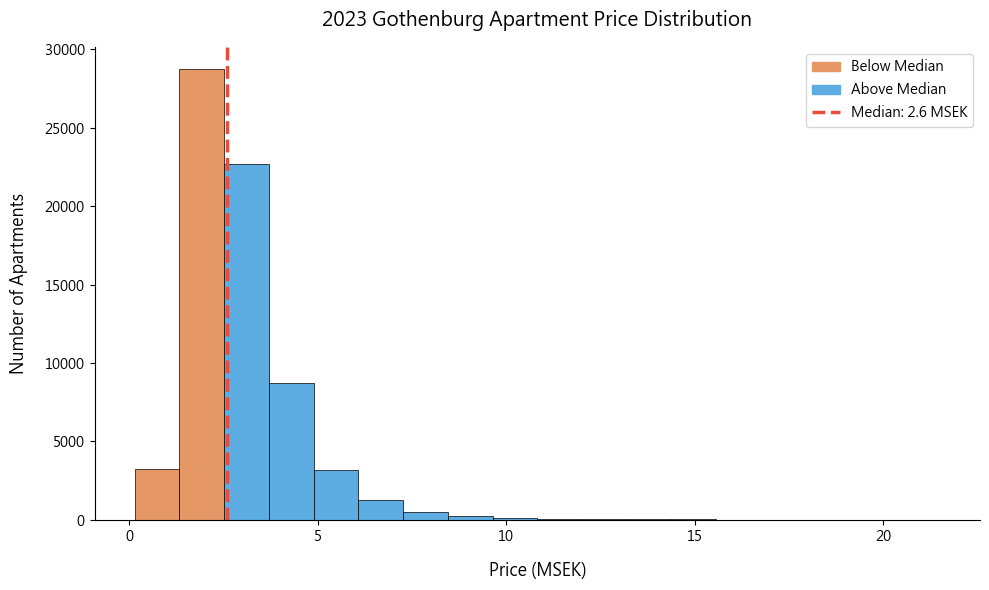

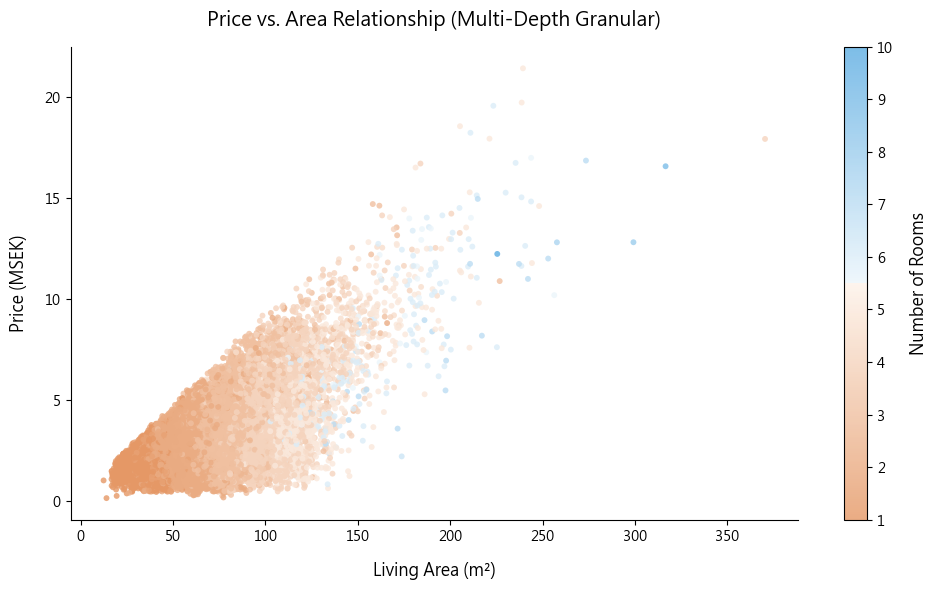

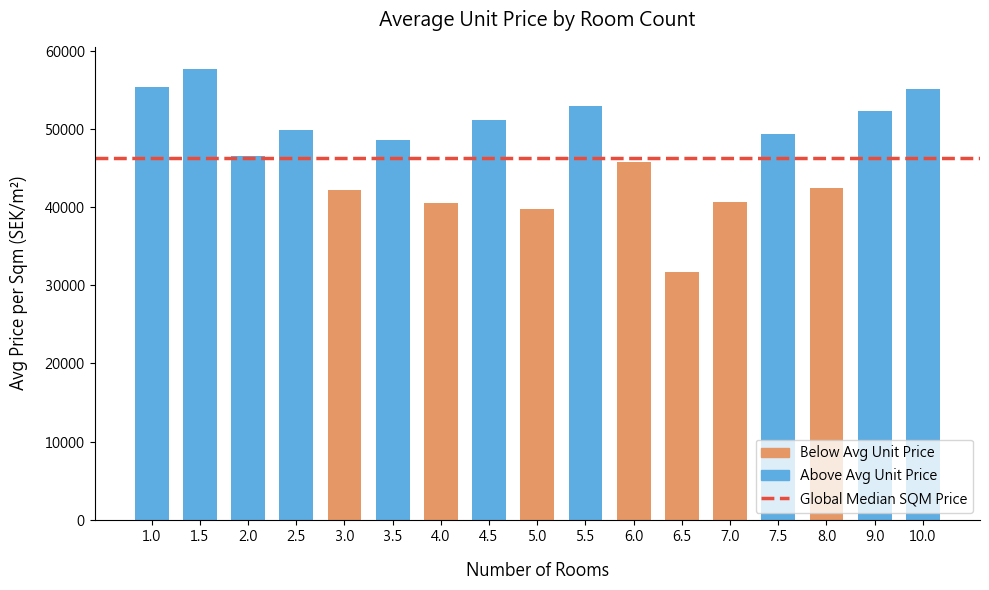

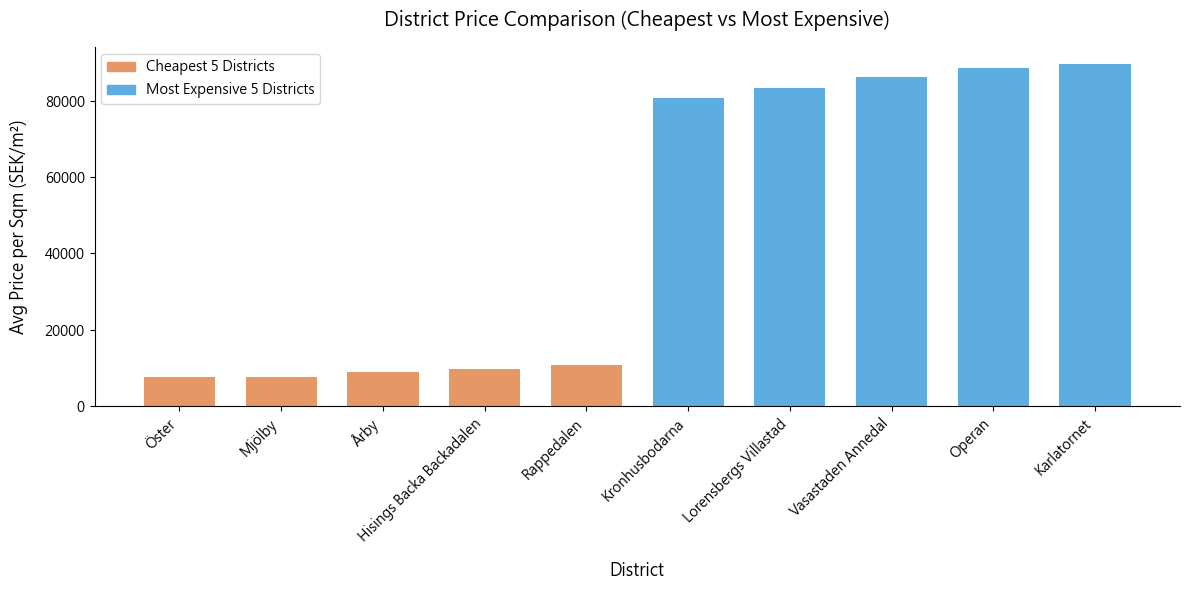

In [7]:
# ==========================================
# CELL 5: VISUALIZATION FUNCTIONS & EXECUTION
# ==========================================

def plot_price_histogram(df: pd.DataFrame):
    """
    Q5: Plots the distribution of apartment prices using a histogram.
    Highlights the median price and separates safe/risk zones.
    """
    if "price" not in df.columns: return
    prices = df["price"].dropna()
    if prices.empty: return

    median_price = prices.median()
    # Sturges' rule for optimal bin count
    bins_count = int(np.ceil(np.log2(len(prices)) + 1)) if len(prices) > 0 else 10

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot Histogram
    counts, bins, patches = ax.hist(
        prices / 1e6,  # Convert to MSEK (Millions)
        bins=bins_count,
        color=SAFE_COLOR,
        edgecolor='black',
        linewidth=0.5
    )

    # Color bins based on median (Visual Cue)
    for patch in patches:
        bin_center_val = (patch.get_x() + patch.get_x() + patch.get_width()) / 2
        if bin_center_val * 1e6 < median_price:
            patch.set_facecolor(RISK_COLOR)

    # Add Median Vertical Line
    ax.axvline(
        median_price / 1e6,
        color=THRESHOLD_COLOR,
        linestyle='--',
        linewidth=2.5
    )

    # Labels and Title
    ax.set_xlabel("Price (MSEK)")
    ax.set_ylabel("Number of Apartments")
    ax.set_title("2023 Gothenburg Apartment Price Distribution")

    # Custom Legend
    legend_elements = [
        mpatches.Patch(color=RISK_COLOR, label='Below Median'),
        mpatches.Patch(color=SAFE_COLOR, label='Above Median'),
        Line2D([0], [0], color=THRESHOLD_COLOR, linewidth=2.5, linestyle='--', label=f'Median: {median_price/1e6:.1f} MSEK')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

def plot_price_area_scatter(df: pd.DataFrame):
    """
    Q6: Scatter plot with manual dual-channel colormap.
    Provides depth for different room counts while physically preventing grey.
    """
    if not {'area', 'price', 'rooms'}.issubset(df.columns): return
    
    plot_df = df.dropna(subset=['area', 'price', 'rooms']).copy()
    if plot_df.empty: return

    from matplotlib.colors import ListedColormap, to_rgb

    c_orange_deep = to_rgb(RISK_COLOR)
    c_orange_pale = to_rgb('#FDF2E9')
    c_blue_pale = to_rgb('#EBF5FB')
    c_blue_deep = to_rgb(SAFE_COLOR)

    orange_grads = np.linspace(c_orange_deep, c_orange_pale, 128)
    blue_grads = np.linspace(c_blue_pale, c_blue_deep, 128)
    custom_cmap = ListedColormap(np.vstack((orange_grads, blue_grads)))

    fig, ax = plt.subplots(figsize=(10, 6))

    price_msek = plot_df["price"] / 1e6
    jittered_area = plot_df["area"] + np.random.normal(0, 1.2, size=len(plot_df))
    jittered_price = price_msek + np.random.normal(0, 0.08, size=len(plot_df))

    scatter = ax.scatter(
        jittered_area,
        jittered_price,
        c=plot_df["rooms"],
        cmap=custom_cmap,
        alpha=0.8,
        s=18,
        edgecolors='none'
    )

    ax.set_xlabel("Living Area (m²)")
    ax.set_ylabel("Price (MSEK)")
    ax.set_title("Price vs. Area Relationship (Multi-Depth Granular)")

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label("Number of Rooms", fontsize=LABEL_SIZE, labelpad=12)
    
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

def plot_psqm_vs_rooms(df: pd.DataFrame):
    """
    Q8: Bar chart showing average Price per Square Meter for different room counts.
    """
    if not {'rooms', 'price_per_sqm'}.issubset(df.columns): return
    
    median_psqm = df["price_per_sqm"].median()
    mean_psqm = df.groupby("rooms")["price_per_sqm"].mean().sort_index()
    if mean_psqm.empty: return

    colors = [RISK_COLOR if p < median_psqm else SAFE_COLOR for p in mean_psqm.values]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        [str(r) for r in mean_psqm.index],
        mean_psqm.values,
        width=0.7,
        color=colors
    )

    ax.axhline(median_psqm, color=THRESHOLD_COLOR, linestyle='--', linewidth=2.5)

    ax.set_xlabel("Number of Rooms")
    ax.set_ylabel("Avg Price per Sqm (SEK/m²)")
    ax.set_title("Average Unit Price by Room Count")

    legend_elements = [
        mpatches.Patch(color=RISK_COLOR, label='Below Avg Unit Price'),
        mpatches.Patch(color=SAFE_COLOR, label='Above Avg Unit Price'),
        Line2D([0], [0], color=THRESHOLD_COLOR, linewidth=2.5, linestyle='--', label='Global Median SQM Price')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

def plot_district_comparison(df: pd.DataFrame):
    """
    Q9: Identifies and plots the Top 5 most expensive and Bottom 5 cheapest districts
    based on average price per square meter.
    """
    if not {'district', 'price_per_sqm'}.issubset(df.columns): return
    
    district_mean = df.groupby("district")["price_per_sqm"].mean().sort_values().dropna()

    if len(district_mean) < 10:
        print("[WARN] Not enough districts to plot top 5 / bottom 5 comparison.")
        return

    combined = pd.concat([district_mean.head(5), district_mean.tail(5)])
    colors = [RISK_COLOR] * 5 + [SAFE_COLOR] * 5

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(combined.index, combined.values, color=colors, width=0.7)

    ax.set_xlabel("District")
    ax.set_ylabel("Avg Price per Sqm (SEK/m²)")
    ax.set_title("District Price Comparison (Cheapest vs Most Expensive)")

    plt.xticks(rotation=45, ha='right')

    legend_elements = [
        mpatches.Patch(color=RISK_COLOR, label='Cheapest 5 Districts'),
        mpatches.Patch(color=SAFE_COLOR, label='Most Expensive 5 Districts')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION PIPELINE (ETL & PLOTTING)
# Training data: 2013–2023 only (2024 reserved for out-of-sample test)
# ==========================================
if __name__ == "__main__":

    # 1. Extract HTML data from the ZIP file
    print("Extracting data from ZIP...")
    html_data_dict = extract_html_from_zip(ZIP_FILE_PATH)
    html_data_dict = {k: v for k, v in html_data_dict.items() if k <= 2023}
    print(f"Loaded years: {sorted(html_data_dict.keys())}")

    # 2. Parse all extracted HTML into a single Raw DataFrame
    print("Parsing HTML to Raw DataFrame...")
    all_raw_dfs = []
    for year, html_content in html_data_dict.items():
        temp_df = parse_html_to_raw_df(html_content)
        all_raw_dfs.append(temp_df)

    # Check if data was successfully parsed
    if all_raw_dfs:
        raw_df = pd.concat(all_raw_dfs, ignore_index=True)
        
        # 3. Clean and Transform the data
        print("Cleaning data...")
        df = clean_housing_data(raw_df)
        
        # 4. Generate the Plots
        print("Generating plots...")
        plot_price_histogram(df)
        plot_price_area_scatter(df)
        plot_psqm_vs_rooms(df)
        plot_district_comparison(df)
    else:
        print("Error: No data was extracted from the ZIP file. Please check ZIP_FILE_PATH.")

## Cell 6 — 特徵工程（建模前置）

複製清理後的 DataFrame，從日期擷取 `year`、`month`，刪除 `address`、`date` 等不相關欄位，以中位數填補 `floor` 缺值，對 `district`、`municipality` 進行 One-Hot 編碼，最終建立特徵矩陣 **X**（586 個特徵）與目標變數 **y**（售價）。

In [8]:
df_model = df.copy()

# Extract temporal features from date before dropping
df_model['date'] = pd.to_datetime(df_model['date'], format='%d %b %Y', errors='coerce')
df_model['year'] = df_model['date'].dt.year
df_model['month'] = df_model['date'].dt.month

# Drop irrelevant columns for modeling
df_model = df_model.drop(columns=['address', 'date'])

# Fill floor NaN with median
df_model['floor'] = df_model['floor'].fillna(df_model['floor'].median())

# Apply one-hot encoding to categorical features
df_model = pd.get_dummies(df_model, columns=['district', 'municipality'], drop_first=True, dtype=int)

# Define the target variable (y) and features (X)
y = df_model['price']
X = df_model.drop(columns=['price', 'price_per_sqm'])

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("\nX columns (first 10):", X.columns.tolist()[:10])
print("\nX head:")
print(X.head())
print("\ny head:")
print(y.head())

Shape of X: (68693, 586)
Shape of y: (68693,)

X columns (first 10): ['area', 'rooms', 'floor', 'year', 'month', 'district_Almedal', 'district_Alt', 'district_Alt Björkekärr', 'district_Alt Centrum', 'district_Alt Norra Guldheden']

X head:
    area  rooms  floor  year  month  district_Almedal  district_Alt  \
0  113.0    5.0    2.0  2013     12                 0             0   
1   66.0    3.0    2.0  2013     12                 0             0   
2   93.0    4.0    3.0  2013     12                 0             0   
3   93.0    4.0    3.0  2013     12                 0             0   
4   50.0    1.5    4.0  2013     12                 0             0   

   district_Alt Björkekärr  district_Alt Centrum  \
0                        0                     0   
1                        0                     0   
2                        0                     0   
3                        0                     0   
4                        0                     0   

   district_Alt Nor

## Cell 7 — 隨機森林模型訓練

將資料以 80/20 切分為訓練集與測試集，初始化並訓練 `RandomForestRegressor`（100 棵決策樹，`n_jobs=-1` 啟用全核心平行運算，`random_state=42` 保證結果可重現）。

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


rfr_model.fit(X_train, y_train)

print("Model training complete.")

Splitting data into training and testing sets...
X_train shape: (54954, 586)
X_test shape: (13739, 586)
y_train shape: (54954,)
y_test shape: (13739,)
Initializing RandomForestRegressor model...
Training the RandomForestRegressor model...
Model training complete.


## Cell 8 — 隨機森林模型評估

對測試集進行預測，計算並輸出三項回歸評估指標：
- **MAE**（Mean Absolute Error，平均絕對誤差）
- **RMSE**（Root Mean Squared Error，均方根誤差）
- **R²**（決定係數）

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred = rfr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Evaluating model performance...
Mean Absolute Error (MAE): 340920.93
Root Mean Squared Error (RMSE): 525623.96
R-squared (R2): 0.85


## Cell 9 — 特徵重要性視覺化

從訓練好的隨機森林取出特徵重要性分數，選取前 10 名，繪製水平長條圖（`viridis` 色票），並將圖片儲存至 `~/Downloads/Top_10_Feature_Importances.png`。

Visualizing feature importance...


C:\Users\tonykuo\AppData\Local\Temp\ipykernel_2872\599894842.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, ax=ax, palette='viridis')


Figure saved successfully: C:\Users\tonykuo\Downloads\Top_10_Feature_Importances.png
Feature importance visualization complete. Check your 'Downloads' folder.


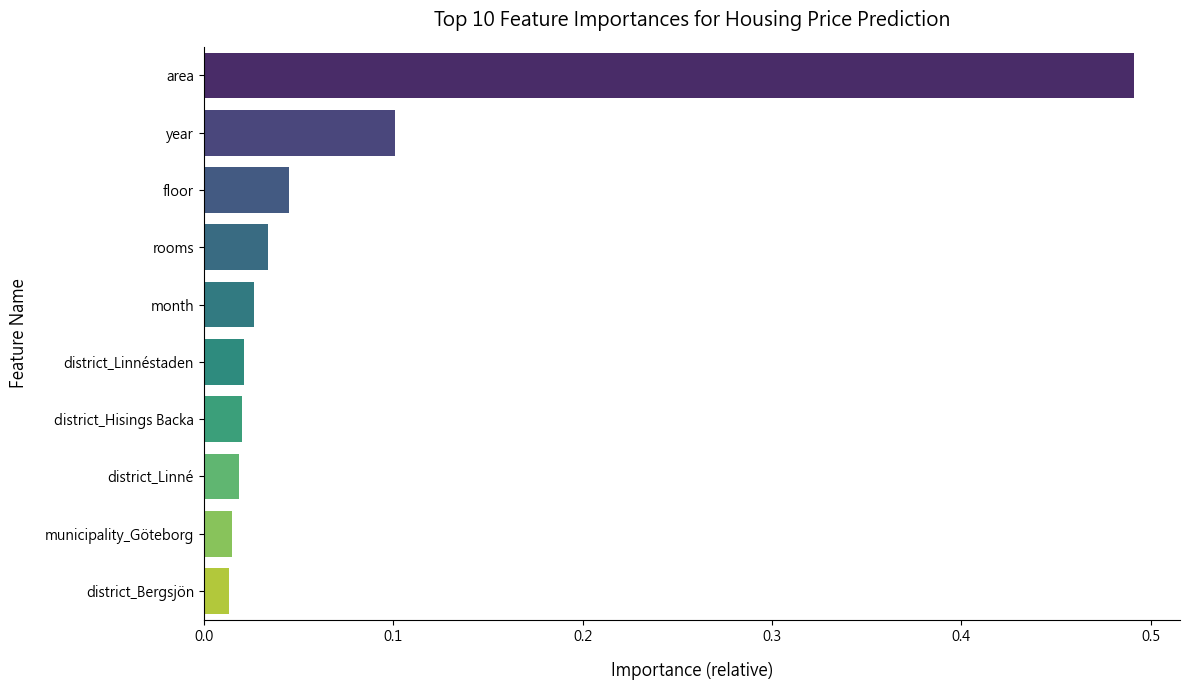

In [ ]:
# Get feature importances
feature_importances = rfr_model.feature_importances_

# Create a DataFrame for feature importances
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order and select the top 10
top_10_features = features_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting the top 10 feature importances
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_features, ax=ax, palette='viridis')

ax.set_title('Top 10 Feature Importances for Housing Price Prediction')
ax.set_xlabel('Importance (relative)')
ax.set_ylabel('Feature Name')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, "Top_10_Feature_Importances.png")

print("Feature importance visualization complete.")

## Cell 10 — 修正 ZIP 解析邏輯並載入 2024 資料

重新定義 `extract_html_from_zip`，改為從**檔名**中解析年份（修正原先依序號遞增的邏輯），確保各年份資料對應正確。接著讀取 2024 年 HTML，解析為 Raw DataFrame 並計算 `price_per_sqm`。

In [12]:
def extract_html_from_zip(zip_path: str) -> Dict[int, str]:
    """
    Extracts HTML content from a ZIP file into memory, parsing the year from the filename.
    """
    data = {}
    path_obj = Path(zip_path)

    if not path_obj.exists():
        print(f"[ERROR] File not found: {zip_path}")
        return data

    try:
        with zipfile.ZipFile(path_obj, "r") as zip_ref:
            for file_name in zip_ref.namelist():
                if not file_name.endswith('.html'):
                    continue
                try:
                    # Corrected logic to extract year from filenames like 'Gothenburg_sold_apartments_YYYY.html'
                    # Expected format: 'name_year.html' or 'name_name_year.html'
                    parts = Path(file_name).stem.split('_')
                    if len(parts) > 1 and parts[-1].isdigit():
                        year = int(parts[-1])
                    else:
                        print(f"[WARN] Could not parse year from filename: {file_name}. Skipping.")
                        continue

                except ValueError:
                    print(f"[WARN] Could not parse year from filename: {file_name}. Skipping.")
                    continue

                with zip_ref.open(file_name) as file:
                    data[year] = file.read().decode('utf-8')
    except Exception as e:
        print(f"[ERROR] Zip extraction failed: {e}")

    return data

print("Redefining extract_html_from_zip with corrected year parsing from filename.")

# Call the updated extract_html_from_zip function
extracted_files_updated = extract_html_from_zip(ZIP_FILE_PATH)

# Check if 2024 data exists and process it
if 2024 not in extracted_files_updated:
    print(f"[CRITICAL] 2024 data not found in {ZIP_FILE_PATH}")
else:
    print("2024 data found. Parsing HTML to raw DataFrame...")
    df_raw_2024 = parse_html_to_raw_df(extracted_files_updated[2024])

    # Convert price and area columns to float
    df_raw_2024['price'] = df_raw_2024['price'].astype(float)
    df_raw_2024['area'] = df_raw_2024['area'].astype(float)

    # Calculate price_per_sqm
    df_raw_2024['price_per_sqm'] = df_raw_2024['price'] / df_raw_2024['area']

    print("df_raw_2024 created and price_per_sqm calculated.")
    print("First 5 rows of df_raw_2024:")
    print(df_raw_2024.head())

Redefining extract_html_from_zip with corrected year parsing from filename.
2024 data found. Parsing HTML to raw DataFrame...
df_raw_2024 created and price_per_sqm calculated.
First 5 rows of df_raw_2024:
             address         date       district municipality      price  \
0     Kobbeslätten 6  12 Nov 2024          Askim     Göteborg  4000000.0   
1  Björklundavägen 8  11 Nov 2024          Hovås     Göteborg  3775000.0   
2  Övre Husargatan 7  11 Nov 2024    Linnéstaden     Göteborg  4060000.0   
3    Hisingsgatan 10  11 Nov 2024  Brämaregården     Göteborg  3495000.0   
4    Vänortsgatan 6B  11 Nov 2024      Bosgården      Mölndal  2690000.0   

   area  rooms  floor  price_per_sqm  
0  89.0    4.0    6.0   44943.820225  
1  68.0    3.0    3.0   55514.705882  
2  62.0    2.0    4.0   65483.870968  
3  98.0    4.0    4.0   35663.265306  
4  76.0    3.0    3.0   35394.736842  


## Cell 11 — 清理 2024 資料並篩選哥德堡市

對 2024 Raw DataFrame 套用 `clean_housing_data` 進行清理（去重、缺值、IQR 異常值移除），再篩選 `municipality == 'Göteborg'`，輸出清理後的筆數與售價五數摘要，作為後續樣本外評估的基礎。

In [ ]:
target_municipality = 'Göteborg'

df_clean_2024 = clean_housing_data(df_raw_2024)

print(f"Filtering for target municipality: {target_municipality}")
df_clean_2024 = df_clean_2024[df_clean_2024['municipality'] == target_municipality].copy()

if df_clean_2024.empty:
    print("[WARN] No data found for the target municipality in 2024 after cleaning.")
else:
    print(f"Found {len(df_clean_2024)} valid transactions for 2024 analysis after cleaning and filtering.")
    print("2024 Price Summary (After Cleaning):")
    print(get_five_point_summary(df_clean_2024["price"]))

Cleaning 2024 raw data...
Initial rows: 6982
Rows after duplicates/NaN/sanity checks: 6947
Checking column 'price_per_sqm':
   - Bounds: 4240.59 to 94122.31
   - Removed 39 statistical outliers.
Final clean rows: 6908 (Total removed: 74)
Filtering for target municipality: Göteborg
Found 6124 valid transactions for 2024 analysis after cleaning and filtering.
2024 Price Summary (After Cleaning):
min         695000.0
Q1         2150000.0
median     2860000.0
Q3         3920000.0
max       26500000.0
dtype: float64


## Cell 12 — 2024 樣本外預測（隨機森林）

對 2024 資料執行與訓練集相同的特徵工程（日期解析、One-Hot 編碼），以 `reindex` 對齊欄位（未見過的地區填 0，多餘欄位忽略），再以隨機森林模型預測，計算 MAE、RMSE、R²，評估模型跨年泛化能力。

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Preparing 2024 data for out-of-sample prediction...")

# Feature engineering for 2024 must mirror the training pipeline exactly
df_test_2024 = df_clean_2024.copy()

# Extract temporal features
df_test_2024['date'] = pd.to_datetime(df_test_2024['date'], format='%d %b %Y', errors='coerce')
df_test_2024['year'] = df_test_2024['date'].dt.year
df_test_2024['month'] = df_test_2024['date'].dt.month

# Drop irrelevant columns
df_test_2024 = df_test_2024.drop(columns=['address', 'date'])

# Fill floor NaN with median
df_test_2024['floor'] = df_test_2024['floor'].fillna(df_test_2024['floor'].median())

# One-hot encode (same schema as training)
df_test_2024 = pd.get_dummies(df_test_2024, columns=['district', 'municipality'], drop_first=True, dtype=int)

# Align columns to match training set X exactly
# - fill_value=0: unseen districts → treated as reference category
# - reindex drops any 2024-only columns not seen in training
X_2024 = df_test_2024.drop(columns=['price', 'price_per_sqm'], errors='ignore')
X_2024 = X_2024.reindex(columns=X.columns, fill_value=0)
y_2024 = df_test_2024['price']

print(f"2024 test samples: {len(X_2024)}")

# Predict
y_pred_2024 = rfr_model.predict(X_2024)

# Evaluate
mae_2024  = mean_absolute_error(y_2024, y_pred_2024)
rmse_2024 = np.sqrt(mean_squared_error(y_2024, y_pred_2024))
r2_2024   = r2_score(y_2024, y_pred_2024)

print("\n2024 Out-of-Sample Evaluation (model trained on 2013–2023):")
print(f"  MAE:  {mae_2024:,.0f} SEK")
print(f"  RMSE: {rmse_2024:,.0f} SEK")
print(f"  R²:   {r2_2024:.4f}")

Preparing 2024 data for out-of-sample prediction...
2024 test samples: 6124

2024 Out-of-Sample Evaluation (model trained on 2013–2023):
  MAE:  659,182 SEK
  RMSE: 979,402 SEK
  R²:   0.6380


## Cell 13 — 診斷 A1：預測值 vs 實際值散佈圖

繪製 2024 年「預測值 vs 實際值」散佈圖，以紅色虛線標示完美預測基準線（y = x），並在標題顯示模型偏差（bias = 預測值 − 實際值 的平均，正值代表高估）。

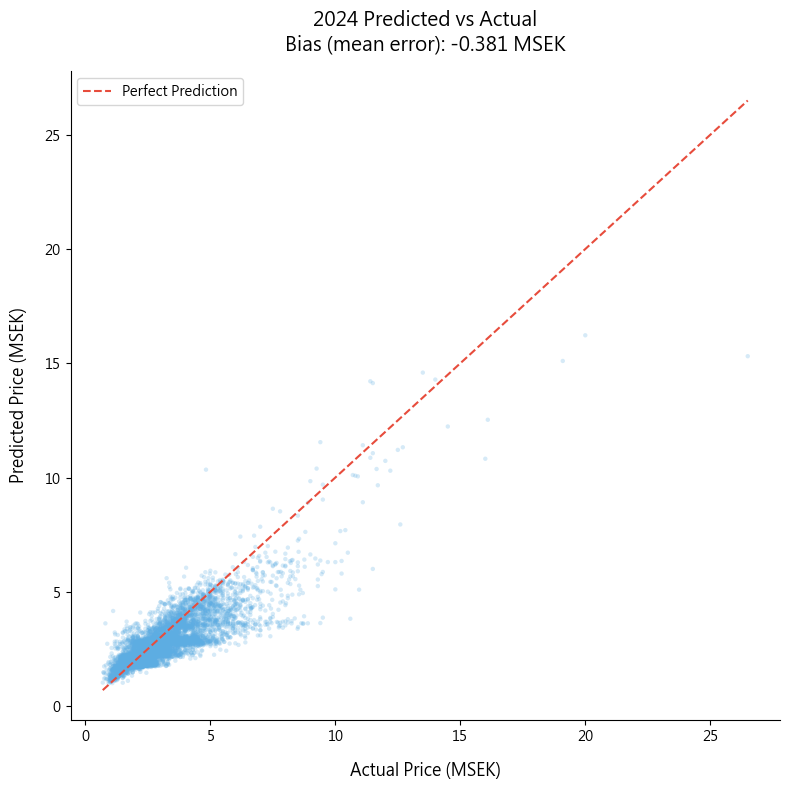

Bias: -380,730 SEK  (underestimating)


In [15]:
# ==========================================
# DIAGNOSTIC A1: Predicted vs Actual Scatter (2024)
# ==========================================
residuals = y_pred_2024 - y_2024.values
bias = residuals.mean()

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_2024 / 1e6,
    y_pred_2024 / 1e6,
    alpha=0.25, s=10, color=SAFE_COLOR, edgecolors='none'
)

# Perfect prediction line
lim_min = min(y_2024.min(), y_pred_2024.min()) / 1e6
lim_max = max(y_2024.max(), y_pred_2024.max()) / 1e6
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color=THRESHOLD_COLOR, linestyle='--', linewidth=1.5, label='Perfect Prediction')

ax.set_xlabel("Actual Price (MSEK)")
ax.set_ylabel("Predicted Price (MSEK)")
ax.set_title(f"2024 Predicted vs Actual\nBias (mean error): {bias/1e6:+.3f} MSEK")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Bias: {bias:+,.0f} SEK  ({'underestimating' if bias < 0 else 'overestimating'})")

## Cell 14 — 診斷 A2：殘差分布與異方差性分析

並排繪製兩張診斷圖：
1. **殘差直方圖**：標示零誤差線與平均偏差，檢視整體誤差的分布形狀與偏斜程度。
2. **殘差 vs 實際售價**：檢查是否存在異方差性（fan-shape），即誤差是否隨售價增大而顯著擴大。

C:\Users\tonykuo\AppData\Local\Temp\ipykernel_2872\1990801843.py:29: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\tonykuo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


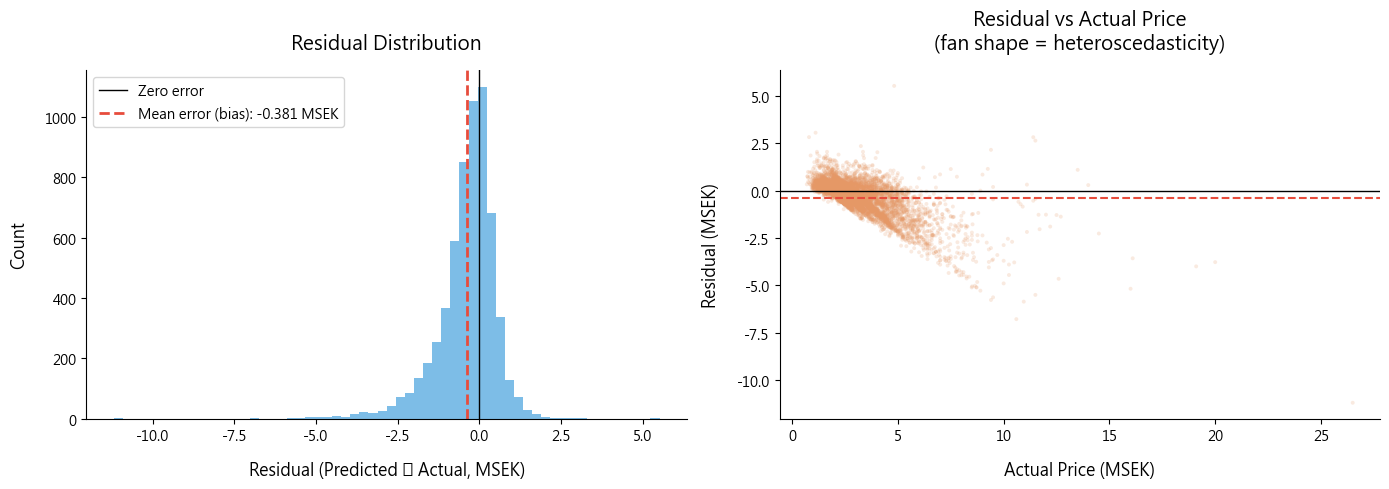

Bias  (mean residual): -0.381 MSEK
Std   (spread):        0.902 MSEK
Skew:                  -1.571


In [16]:
# ==========================================
# DIAGNOSTIC A2: Residual Distribution (Bias vs Variance)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residual histogram
ax = axes[0]
ax.hist(residuals / 1e6, bins=60, color=SAFE_COLOR, edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=1, label='Zero error')
ax.axvline(bias / 1e6, color=THRESHOLD_COLOR, linestyle='--', linewidth=2,
           label=f'Mean error (bias): {bias/1e6:+.3f} MSEK')
ax.set_xlabel("Residual (Predicted − Actual, MSEK)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend()
sns.despine(ax=ax)

# Right: Residual vs Actual (heteroscedasticity check)
ax = axes[1]
ax.scatter(y_2024 / 1e6, residuals / 1e6,
           alpha=0.2, s=8, color=RISK_COLOR, edgecolors='none')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axhline(bias / 1e6, color=THRESHOLD_COLOR, linestyle='--', linewidth=1.5)
ax.set_xlabel("Actual Price (MSEK)")
ax.set_ylabel("Residual (MSEK)")
ax.set_title("Residual vs Actual Price\n(fan shape = heteroscedasticity)")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"Bias  (mean residual): {bias/1e6:+.3f} MSEK")
print(f"Std   (spread):        {residuals.std()/1e6:.3f} MSEK")
print(f"Skew:                  {pd.Series(residuals).skew():.3f}")

## Cell 15 — 診斷 C1：各地區預測誤差分析

按地區統計平均偏差（mean bias）與 MAE，列出預測表現最差的前 15 個地區；並以水平長條圖顯示樣本數最多的 20 個地區的偏差方向（正值 = 系統性高估，負值 = 系統性低估）。

Top 15 districts by MAE (prediction obstacles):
                   count     mean_bias           mae
district                                            
Örgryte Torp          10 -2.008095e+06  2.008095e+06
Nedre Johanneberg     30 -1.580892e+06  1.768359e+06
Inom Vallgraven       28 -1.290037e+06  1.422594e+06
Haga                  12 -1.351289e+06  1.399414e+06
Kungshöjd             51 -1.351061e+06  1.351061e+06
Vasastaden           127 -9.851649e+05  1.213503e+06
Centrum              311 -1.033344e+06  1.137145e+06
Örgryte              100 -1.078177e+06  1.122070e+06
Sannegårdshamnen      46 -1.093723e+06  1.102880e+06
Agnesberg             14  1.088413e+06  1.088413e+06
Sannegården           22 -9.192036e+05  1.035067e+06
Lorensberg           106 -7.866616e+05  1.028532e+06
Nordost               20  9.258559e+05  1.007247e+06
Landala Egnahem       24 -9.659838e+05  9.993130e+05
Heden                 16 -9.693054e+05  9.845179e+05


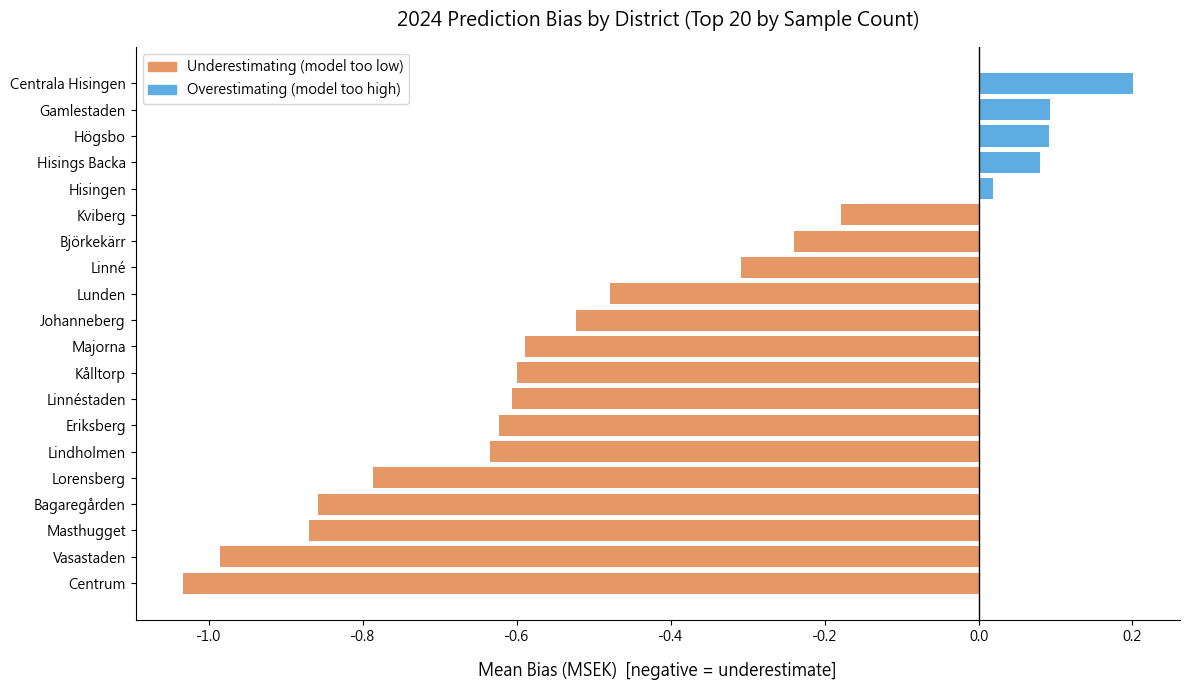

In [17]:
# ==========================================
# DIAGNOSTIC C1: Error Breakdown by District
# Find which districts are the prediction obstacles
# ==========================================
diag_df = df_clean_2024[['district', 'price']].copy().reset_index(drop=True)
diag_df['predicted'] = y_pred_2024
diag_df['residual']  = y_pred_2024 - diag_df['price']
diag_df['abs_error'] = diag_df['residual'].abs()

district_err = (
    diag_df.groupby('district')
    .agg(
        count=('abs_error', 'count'),
        mean_bias=('residual', 'mean'),       # positive = overestimate, negative = underestimate
        mae=('abs_error', 'mean'),
    )
    .query('count >= 10')                     # only districts with enough samples
    .sort_values('mae', ascending=False)
)

print("Top 15 districts by MAE (prediction obstacles):")
print(district_err.head(15).to_string())

# Plot: bias by district (top 20 by sample count)
top_districts = district_err.sort_values('count', ascending=False).head(20).sort_values('mean_bias')

fig, ax = plt.subplots(figsize=(12, 7))
colors = [RISK_COLOR if b < 0 else SAFE_COLOR for b in top_districts['mean_bias']]
ax.barh(top_districts.index, top_districts['mean_bias'] / 1e6, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("Mean Bias (MSEK)  [negative = underestimate]")
ax.set_title("2024 Prediction Bias by District (Top 20 by Sample Count)")

legend_elements = [
    mpatches.Patch(color=RISK_COLOR, label='Underestimating (model too low)'),
    mpatches.Patch(color=SAFE_COLOR, label='Overestimating (model too high)'),
]
ax.legend(handles=legend_elements)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Cell 16 — 診斷 C2：時間特徵重要性確認

確認 `year`、`month` 在隨機森林中的重要性排名與順位，繪製前 15 名特徵重要性圖，以紅色標示時間特徵，評估模型是否有效學習到跨年的市場趨勢信號。

Total features: 586

Temporal feature ranking:
Feature  Importance  Rank
   year    0.101201     2
  month    0.026550     5


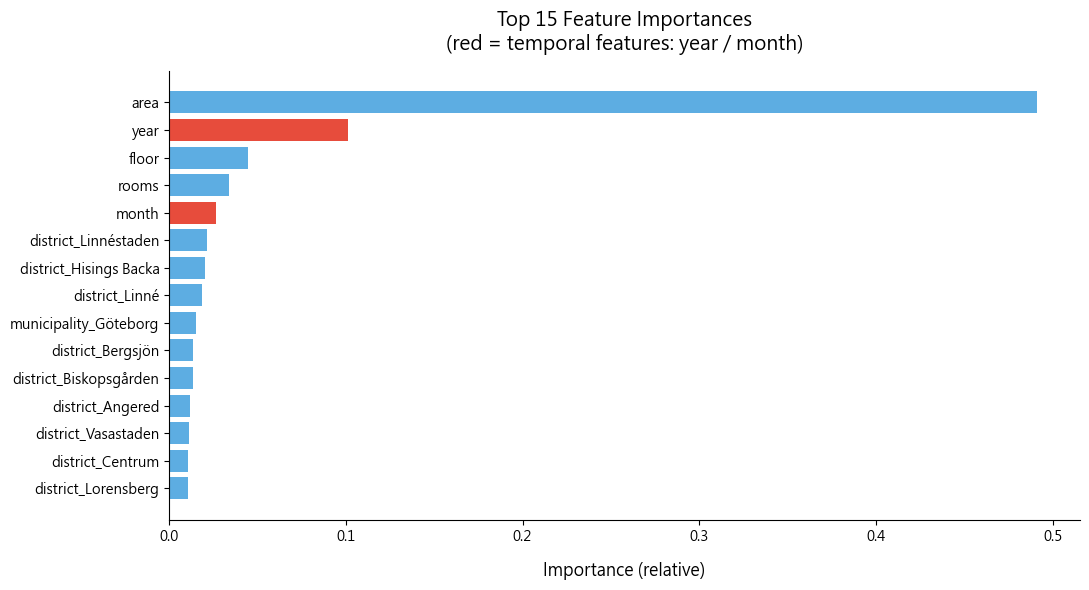

In [18]:
# ==========================================
# DIAGNOSTIC C2: Feature Importance — Temporal Signal Check
# Did the model learn year/month trends?
# ==========================================
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfr_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Show where year and month rank
temporal_rank = fi_df[fi_df['Feature'].isin(['year', 'month'])][['Feature', 'Importance']]
total_features = len(fi_df)
temporal_rank = temporal_rank.copy()
temporal_rank['Rank'] = temporal_rank['Importance'].apply(
    lambda imp: (fi_df['Importance'] > imp).sum() + 1
)
print(f"Total features: {total_features}")
print("\nTemporal feature ranking:")
print(temporal_rank.to_string(index=False))

# Plot top 15 features, highlighting year and month
top15 = fi_df.head(15)
colors = [THRESHOLD_COLOR if f in ('year', 'month') else SAFE_COLOR for f in top15['Feature']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1])
ax.set_xlabel("Importance (relative)")
ax.set_title("Top 15 Feature Importances\n(red = temporal features: year / month)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Cell 17 — 改進模型：HistGradientBoosting + log(price)

以 `log(price)` 作為目標變數訓練 `HistGradientBoostingRegressor`（300 次迭代），解決隨機森林對高端房價的異方差問題；使用相同的 80/20 切分，與隨機森林在訓練集內部測試指標（MAE、RMSE、R²）上進行比較。

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training new model: HistGradientBoostingRegressor + log(price) target")
print("Rationale:")
print("  - log(price) fixes heteroscedasticity (compresses high-price tail)")
print("  - HistGBR builds residuals sequentially → better extrapolation than RF")
print("  - HistGBR handles NaN natively (no fillna needed)")
print()

# Log-transform target variable
y_log = np.log(y)

# Same split as RF for fair comparison
X_train2, X_test2, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, shuffle=True
)
y_test2_orig = np.exp(y_log_test)  # back to SEK for evaluation

# HistGBR: histogram-based, fast on large datasets, good extrapolation
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb_model.fit(X_train2, y_log_train)
print("Training complete.")

# In-sample evaluation (original price scale)
y_pred_test2_orig = np.exp(hgb_model.predict(X_test2))

mae_hgb_in  = mean_absolute_error(y_test2_orig, y_pred_test2_orig)
rmse_hgb_in = np.sqrt(mean_squared_error(y_test2_orig, y_pred_test2_orig))
r2_hgb_in   = r2_score(y_test2_orig, y_pred_test2_orig)

print(f"\nIn-sample test (2013–2023 random split):")
print(f"  {'Model':<30} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print(f"  {'-'*65}")
print(f"  {'RF (original)':<30} {'432,480':>12} {'649,203':>12} {'0.7800':>8}")
print(f"  {'HGB + log(price)':<30} {mae_hgb_in:>12,.0f} {rmse_hgb_in:>12,.0f} {r2_hgb_in:>8.4f}")

Training new model: HistGradientBoostingRegressor + log(price) target
Rationale:
  - log(price) fixes heteroscedasticity (compresses high-price tail)
  - HistGBR builds residuals sequentially → better extrapolation than RF
  - HistGBR handles NaN natively (no fillna needed)

Training complete.

In-sample test (2013–2023 random split):
  Model                                   MAE         RMSE       R²
  -----------------------------------------------------------------
  RF (original)                       432,480      649,203   0.7800
  HGB + log(price)                    383,287      564,003   0.8272


## Cell 18 — 2024 樣本外比較：RF vs HGB

將 HGB 模型應用於 2024 樣本外資料，與隨機森林並排比較：
- 輸出評估指標對照表（MAE、RMSE、R²、Bias）。
- 預測 vs 實際散佈圖（各一張並排）。
- 殘差直方圖（各一張並排），觀察誤差分布的改善情況。

Evaluating HGB + log(price) on 2024 out-of-sample data...

=== 2024 Out-of-Sample Comparison ===
  Model                                   MAE         RMSE       R²     Bias (SEK)
  --------------------------------------------------------------------------------
  RF (original)                       659,182      979,402   0.6380       -381,000
  HGB + log(price)                    557,311      870,789   0.7139       -346,481


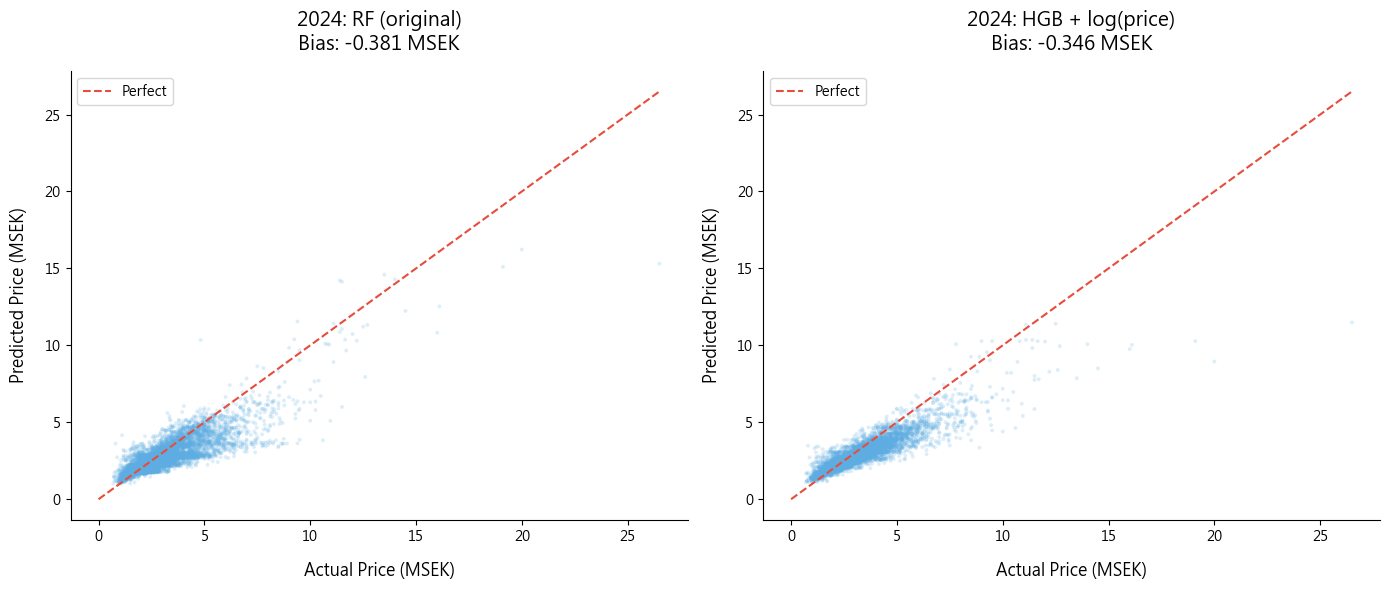

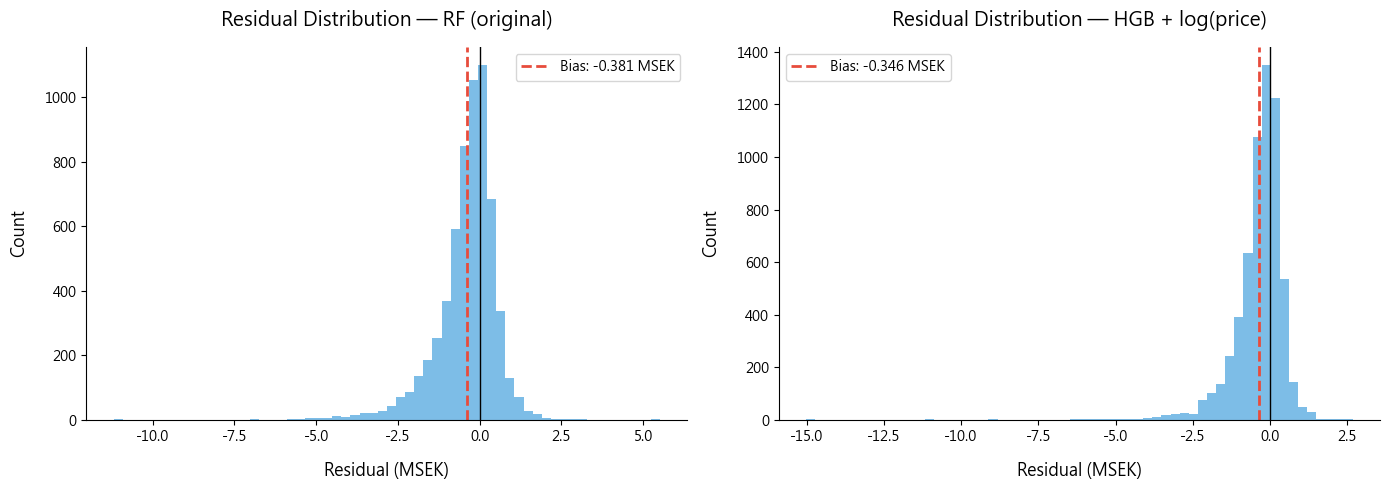

In [20]:
# ==========================================
# 2024 OUT-OF-SAMPLE: RF vs HGB comparison
# ==========================================
print("Evaluating HGB + log(price) on 2024 out-of-sample data...")

y_pred_2024_hgb = np.exp(hgb_model.predict(X_2024))

mae_hgb_oos  = mean_absolute_error(y_2024, y_pred_2024_hgb)
rmse_hgb_oos = np.sqrt(mean_squared_error(y_2024, y_pred_2024_hgb))
r2_hgb_oos   = r2_score(y_2024, y_pred_2024_hgb)
bias_hgb     = (y_pred_2024_hgb - y_2024.values).mean()

print(f"\n=== 2024 Out-of-Sample Comparison ===")
print(f"  {'Model':<30} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'Bias (SEK)':>14}")
print(f"  {'-'*80}")
print(f"  {'RF (original)':<30} {'659,182':>12} {'979,402':>12} {'0.6380':>8} {'-381,000':>14}")
print(f"  {'HGB + log(price)':<30} {mae_hgb_oos:>12,.0f} {rmse_hgb_oos:>12,.0f} {r2_hgb_oos:>8.4f} {bias_hgb:>+14,.0f}")

# Side-by-side scatter plot
residuals_hgb = y_pred_2024_hgb - y_2024.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred_col, title, bias_val in zip(
    axes,
    [y_pred_2024,     y_pred_2024_hgb],
    ["RF (original)", "HGB + log(price)"],
    [bias,             bias_hgb]
):
    ax.scatter(y_2024 / 1e6, y_pred_col / 1e6,
               alpha=0.2, s=8, color=SAFE_COLOR, edgecolors='none')
    lim = max(y_2024.max(), y_pred_col.max()) / 1e6
    ax.plot([0, lim], [0, lim],
            color=THRESHOLD_COLOR, linestyle='--', linewidth=1.5, label='Perfect')
    ax.set_xlabel("Actual Price (MSEK)")
    ax.set_ylabel("Predicted Price (MSEK)")
    ax.set_title(f"2024: {title}\nBias: {bias_val/1e6:+.3f} MSEK")
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Residual histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, resid, title in zip(
    axes,
    [y_pred_2024 - y_2024.values, residuals_hgb],
    ["RF (original)", "HGB + log(price)"]
):
    ax.hist(resid / 1e6, bins=60, color=SAFE_COLOR, edgecolor='none', alpha=0.8)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(resid.mean() / 1e6, color=THRESHOLD_COLOR, linestyle='--', linewidth=2,
               label=f'Bias: {resid.mean()/1e6:+.3f} MSEK')
    ax.set_xlabel("Residual (MSEK)")
    ax.set_ylabel("Count")
    ax.set_title(f"Residual Distribution — {title}")
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## Cell 19 — 改進策略 A：事後偏差修正（Post-hoc Bias Correction）

計算 HGB 模型在 2013–2023 驗證集上的平均殘差（in-sample bias），將其從所有 2024 預測值中減去，修正系統性低估。比較修正前後的 MAE、RMSE、R²、Bias 變化。

In [21]:
# ==========================================
# APPROACH A: Post-hoc Bias Correction
# Use in-sample test residuals to estimate systematic underestimation,
# then shift all 2024 predictions up by that amount.
# ==========================================

# val_bias = mean(pred - actual) on the 2013-2023 held-out test set
# (using in-sample data so 2024 is NOT touched → no leakage)
val_bias = (y_pred_test2_orig - y_test2_orig.values).mean()

print(f"In-sample validation bias : {val_bias:+,.0f} SEK")
print(f"2024 observed bias        : {bias_hgb:+,.0f} SEK")
print(f"  → The 2024 market drifted {(bias_hgb - val_bias)/1e6:.3f} MSEK beyond in-sample patterns")
print()

# Subtract in-sample bias from 2024 predictions
# (val_bias is negative → subtracting a negative pushes predictions UP)
y_pred_2024_debiased = y_pred_2024_hgb - val_bias

mae_db  = mean_absolute_error(y_2024, y_pred_2024_debiased)
rmse_db = np.sqrt(mean_squared_error(y_2024, y_pred_2024_debiased))
r2_db   = r2_score(y_2024, y_pred_2024_debiased)
bias_db = (y_pred_2024_debiased - y_2024.values).mean()

print(f"=== 2024: HGB + Bias Correction ===")
print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'Bias':>14}")
print(f"  {'-'*75}")
print(f"  {'HGB + log':<25} {mae_hgb_oos:>12,.0f} {rmse_hgb_oos:>12,.0f} {r2_hgb_oos:>8.4f} {bias_hgb:>+14,.0f}")
print(f"  {'HGB + log + debias':<25} {mae_db:>12,.0f} {rmse_db:>12,.0f} {r2_db:>8.4f} {bias_db:>+14,.0f}")

In-sample validation bias : -79,241 SEK
2024 observed bias        : -346,481 SEK
  → The 2024 market drifted -0.267 MSEK beyond in-sample patterns

=== 2024: HGB + Bias Correction ===
  Model                              MAE         RMSE       R²           Bias
  ---------------------------------------------------------------------------
  HGB + log                      557,311      870,789   0.7139       -346,481
  HGB + log + debias             537,243      842,402   0.7322       -267,240


## Cell 20 — 改進策略 B：高端房市分層模型（Stratified High-End Model）

對售價超過 800 萬 SEK 的豪宅單獨訓練一個 HGB 專屬模型（500 次迭代、較淺的樹深），在 400–800 萬 SEK 區間以線性 alpha 值平滑混合主模型與專屬模型；分別評估 B 策略與 A+B 合併策略的效果。

In [22]:
# ==========================================
# APPROACH B: Stratified High-End Model
# Train a specialist model on luxury apartments (>8 MSEK).
# Route predictions via smooth blending based on the main model's output.
# ==========================================
PRICE_THRESHOLD = 8_000_000  # 8 MSEK = luxury boundary
BLEND_START     = 4_000_000  # start mixing in high-end model at 4 MSEK
BLEND_END       = 8_000_000  # fully use high-end model above 8 MSEK

high_mask = (y > PRICE_THRESHOLD)
X_high    = X[high_mask]
y_high_log = np.log(y[high_mask])

print(f"High-end training samples (> {PRICE_THRESHOLD/1e6:.0f} MSEK): "
      f"{high_mask.sum():,}  ({high_mask.mean()*100:.1f}% of training data)")

# Specialist model: more iterations + shallower depth
# (smaller dataset → risk of overfit with deep trees)
hgb_high = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)
hgb_high.fit(X_high, y_high_log)
print("High-end specialist model trained.")

# Smooth blending:
#   alpha = 0 → pure main model (cheap apartments)
#   alpha = 1 → pure high-end model (luxury apartments)
# Routing signal = main model's prediction (not actual price → no leakage)
p_main = y_pred_2024_hgb.copy()
p_high = np.exp(hgb_high.predict(X_2024))

alpha = np.clip((p_main - BLEND_START) / (BLEND_END - BLEND_START), 0, 1)
y_pred_2024_strat = (1 - alpha) * p_main + alpha * p_high

mae_st  = mean_absolute_error(y_2024, y_pred_2024_strat)
rmse_st = np.sqrt(mean_squared_error(y_2024, y_pred_2024_strat))
r2_st   = r2_score(y_2024, y_pred_2024_strat)
bias_st = (y_pred_2024_strat - y_2024.values).mean()

print(f"\n=== 2024: Stratified Model ===")
print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'Bias':>14}")
print(f"  {'-'*75}")
print(f"  {'HGB + log':<25} {mae_hgb_oos:>12,.0f} {rmse_hgb_oos:>12,.0f} {r2_hgb_oos:>8.4f} {bias_hgb:>+14,.0f}")
print(f"  {'HGB stratified':<25} {mae_st:>12,.0f} {rmse_st:>12,.0f} {r2_st:>8.4f} {bias_st:>+14,.0f}")

# Also try A+B combined: stratified + bias correction
y_pred_2024_strat_db = y_pred_2024_strat - val_bias
mae_stdb  = mean_absolute_error(y_2024, y_pred_2024_strat_db)
rmse_stdb = np.sqrt(mean_squared_error(y_2024, y_pred_2024_strat_db))
r2_stdb   = r2_score(y_2024, y_pred_2024_strat_db)
bias_stdb = (y_pred_2024_strat_db - y_2024.values).mean()

print(f"  {'HGB strat + debias':<25} {mae_stdb:>12,.0f} {rmse_stdb:>12,.0f} {r2_stdb:>8.4f} {bias_stdb:>+14,.0f}")

High-end training samples (> 8 MSEK): 563  (0.8% of training data)
High-end specialist model trained.

=== 2024: Stratified Model ===
  Model                              MAE         RMSE       R²           Bias
  ---------------------------------------------------------------------------
  HGB + log                      557,311      870,789   0.7139       -346,481
  HGB stratified                 518,951      760,625   0.7817       -260,804
  HGB strat + debias             502,860      737,222   0.7949       -181,562


## Cell 21 — 最終比較：所有模型彙整

彙整五個模型在 2024 樣本外的完整指標（MAE、RMSE、R²、Bias）並輸出對照表，同時以五張並排散佈圖呈現各模型的預測分布，直觀比較各策略對精度的貢獻。

Model                                 MAE         RMSE       R²           Bias
------------------------------------------------------------------------------
RF (baseline)                     659,182      979,402   0.6380       -381,000
HGB + log                         557,311      870,789   0.7139       -346,481
HGB + debias (A)                  537,243      842,402   0.7322       -267,240
HGB + stratified (B)              518,951      760,625   0.7817       -260,804
HGB + strat + debias              502,860      737,222   0.7949       -181,562


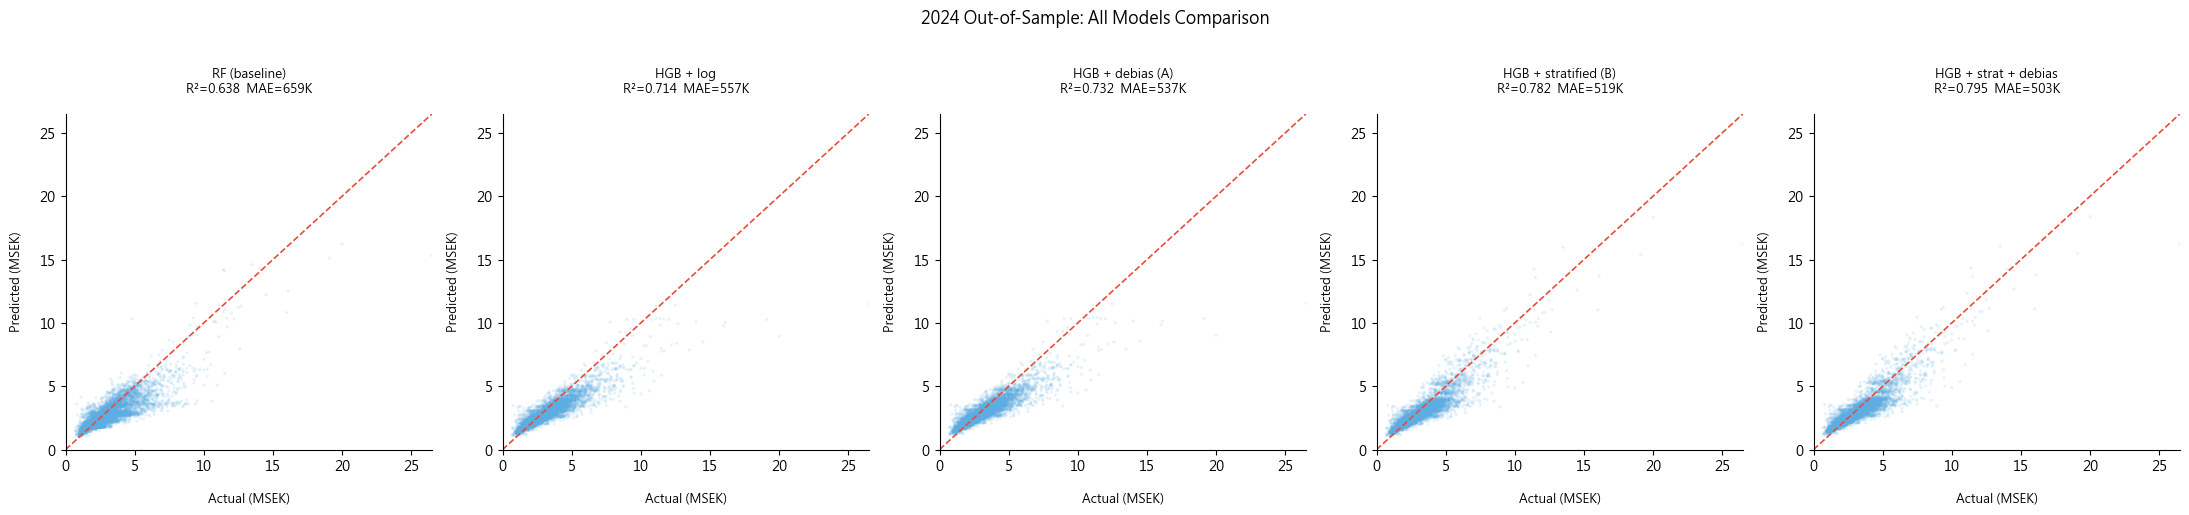

In [23]:
# ==========================================
# FINAL SUMMARY: All Models on 2024 Out-of-Sample
# ==========================================
models = {
    "RF (baseline)":        (y_pred_2024,          659182,  979402,  0.6380, -381000),
    "HGB + log":            (y_pred_2024_hgb,       mae_hgb_oos,  rmse_hgb_oos,  r2_hgb_oos,  bias_hgb),
    "HGB + debias (A)":     (y_pred_2024_debiased,  mae_db,  rmse_db,  r2_db,  bias_db),
    "HGB + stratified (B)": (y_pred_2024_strat,     mae_st,  rmse_st,  r2_st,  bias_st),
    "HGB + strat + debias": (y_pred_2024_strat_db,  mae_stdb, rmse_stdb, r2_stdb, bias_stdb),
}

print(f"{'Model':<28} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'Bias':>14}")
print("-" * 78)
for name, (_, mae, rmse, r2, bias_val) in models.items():
    print(f"{name:<28} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.4f} {bias_val:>+14,.0f}")

# Scatter comparison: 5 panels
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
lim = y_2024.max() / 1e6

for ax, (name, (y_pred_col, mae, rmse, r2, bias_val)) in zip(axes, models.items()):
    ax.scatter(y_2024 / 1e6, y_pred_col / 1e6,
               alpha=0.15, s=5, color=SAFE_COLOR, edgecolors='none')
    ax.plot([0, lim], [0, lim],
            color=THRESHOLD_COLOR, linestyle='--', linewidth=1.2)
    ax.set_xlabel("Actual (MSEK)", fontsize=9)
    ax.set_ylabel("Predicted (MSEK)", fontsize=9)
    ax.set_title(f"{name}\nR²={r2:.3f}  MAE={mae/1e3:.0f}K", fontsize=9)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    sns.despine(ax=ax)

plt.suptitle("2024 Out-of-Sample: All Models Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Cell 22 — 改進策略 C：歷史價格趨勢外推（Trend Extrapolation）

以線性迴歸擬合 2013–2023 年每坪中位數售價的對數線性趨勢，計算年均漲幅與 2024 年外推倍數（multiplier），並以折線圖視覺化歷史趨勢線、擬合值與外推點。

Annual median price/m² (training data):
 year  median_psqm
 2013 29411.764706
 2014 32978.723404
 2015 39950.000000
 2016 43466.666667
 2017 48688.524590
 2018 47435.897436
 2019 47363.455809
 2020 49275.362319
 2021 52252.252252
 2022 51025.641026
 2023 48571.428571

Fitted annual appreciation rate: 4.92%
Trend multiplier (2024/2023):   1.0492  (4.92%)


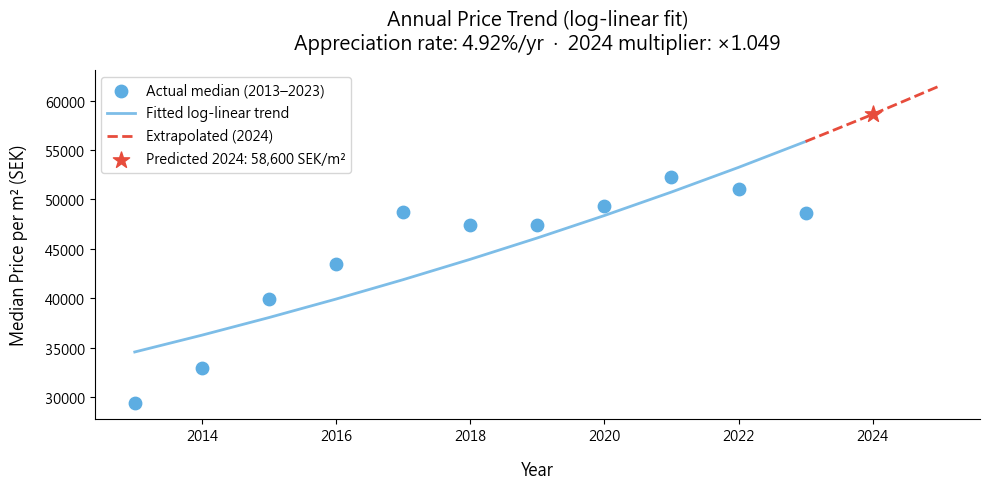

In [24]:
from sklearn.linear_model import LinearRegression

# ==========================================
# APPROACH C: Trend Extrapolation
# Fit a log-linear price trend on 2013-2023 annual medians,
# extrapolate to 2024, and apply as a multiplicative correction.
# ==========================================

# Compute annual median price_per_sqm from training data
df_trend = df.copy()
df_trend['year'] = pd.to_datetime(df_trend['date'], format='%d %b %Y', errors='coerce').dt.year

annual_idx = (
    df_trend.groupby('year')['price_per_sqm']
    .median()
    .reset_index()
    .rename(columns={'price_per_sqm': 'median_psqm'})
)
print("Annual median price/m² (training data):")
print(annual_idx.to_string(index=False))

# Fit log-linear trend: log(price_per_sqm) ~ year
X_yr  = annual_idx['year'].values.reshape(-1, 1)
y_log_trend = np.log(annual_idx['median_psqm'].values)
lr = LinearRegression().fit(X_yr, y_log_trend)

annual_rate = np.exp(lr.coef_[0]) - 1
print(f"\nFitted annual appreciation rate: {annual_rate*100:.2f}%")

# Extrapolate to 2024
psqm_2023 = np.exp(lr.predict([[2023]])[0])
psqm_2024 = np.exp(lr.predict([[2024]])[0])
multiplier_global = psqm_2024 / psqm_2023
print(f"Trend multiplier (2024/2023):   {multiplier_global:.4f}  ({(multiplier_global-1)*100:.2f}%)")

# Visualise trend + extrapolation
years_plot = np.arange(2013, 2026)
psqm_fitted = np.exp(lr.predict(years_plot.reshape(-1, 1)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(annual_idx['year'], annual_idx['median_psqm'],
           color=SAFE_COLOR, s=80, zorder=5, label='Actual median (2013–2023)')
ax.plot(years_plot[:11], psqm_fitted[:11],
        color=SAFE_COLOR, linewidth=2, alpha=0.8, label='Fitted log-linear trend')
ax.plot(years_plot[10:], psqm_fitted[10:],
        color=THRESHOLD_COLOR, linewidth=2, linestyle='--', label='Extrapolated (2024)')
ax.scatter([2024], [psqm_2024], color=THRESHOLD_COLOR, s=150, zorder=6, marker='*',
           label=f'Predicted 2024: {psqm_2024:,.0f} SEK/m²')

ax.set_xlabel("Year")
ax.set_ylabel("Median Price per m² (SEK)")
ax.set_title(f"Annual Price Trend (log-linear fit)\n"
             f"Appreciation rate: {annual_rate*100:.2f}%/yr  ·  "
             f"2024 multiplier: ×{multiplier_global:.3f}")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Cell 23 — 套用趨勢倍數並輸出最終結果

將趨勢外推倍數乘以 A+B 組合的預測值（策略 C），輸出包含 RF 基準至 A+B+C 完整策略的最終對照表，並繪製 R² 改善歷程長條圖，展示每個策略帶來的性能提升幅度。

=== Final 2024 Out-of-Sample Comparison ===

Model                                 MAE       RMSE       R²         Bias
--------------------------------------------------------------------------
RF (baseline)                     659,182    979,402   0.6380     -381,000
HGB + log                         557,311    870,789   0.7139     -346,481
+ debias (A)                      537,243    842,402   0.7322     -267,240
+ stratified (B)                  518,951    760,625   0.7817     -260,804
+ strat + debias (A+B)            502,860    737,222   0.7949     -181,562
+ trend ×1.049 (A+B+C)            487,876    706,607   0.8116      -31,645


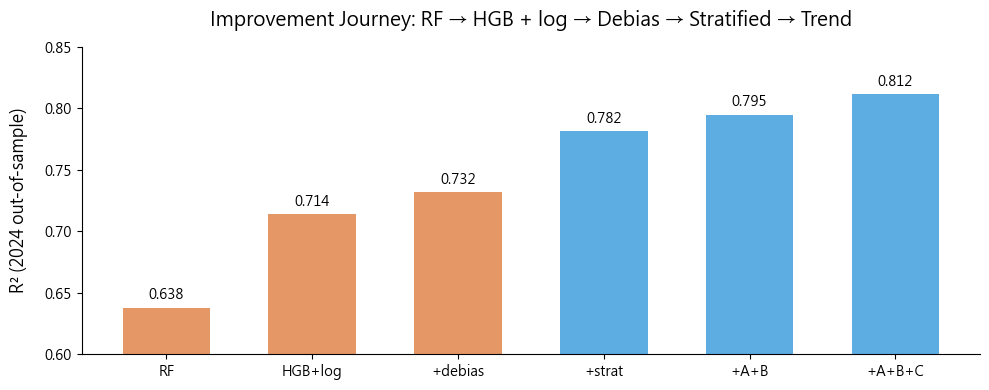

In [25]:
# ==========================================
# APPROACH C: Apply trend multiplier + full comparison
# ==========================================

# Apply to best model so far (HGB + strat + debias)
y_pred_2024_trend = y_pred_2024_strat_db * multiplier_global

mae_tr  = mean_absolute_error(y_2024, y_pred_2024_trend)
rmse_tr = np.sqrt(mean_squared_error(y_2024, y_pred_2024_trend))
r2_tr   = r2_score(y_2024, y_pred_2024_trend)
bias_tr = (y_pred_2024_trend - y_2024.values).mean()

print(f"=== Final 2024 Out-of-Sample Comparison ===\n")
print(f"{'Model':<30} {'MAE':>10} {'RMSE':>10} {'R²':>8} {'Bias':>12}")
print(f"{'-'*74}")
rows = [
    ("RF (baseline)",           659182,      979402,  0.6380,  -381000),
    ("HGB + log",               mae_hgb_oos, rmse_hgb_oos, r2_hgb_oos, bias_hgb),
    ("+ debias (A)",            mae_db,      rmse_db,  r2_db,   bias_db),
    ("+ stratified (B)",        mae_st,      rmse_st,  r2_st,   bias_st),
    ("+ strat + debias (A+B)",  mae_stdb,    rmse_stdb, r2_stdb, bias_stdb),
    ("+ trend ×{:.3f} (A+B+C)".format(multiplier_global), mae_tr, rmse_tr, r2_tr, bias_tr),
]
for name, mae, rmse, r2, bias_val in rows:
    print(f"{name:<30} {mae:>10,.0f} {rmse:>10,.0f} {r2:>8.4f} {bias_val:>+12,.0f}")

# R² improvement journey bar chart
labels = ["RF", "HGB+log", "+debias", "+strat", "+A+B", "+A+B+C"]
r2_vals = [r[3] for r in rows]
colors  = [RISK_COLOR if v < 0.75 else SAFE_COLOR for v in r2_vals]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, r2_vals, color=colors, width=0.6)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_ylim(0.6, 0.85)
ax.set_ylabel("R² (2024 out-of-sample)")
ax.set_title("Improvement Journey: RF → HGB + log → Debias → Stratified → Trend")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()